In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.fft import fft, rfft, fftfreq, rfftfreq
from scipy.optimize import curve_fit, minimize
from lmfit import Model

In [2]:
def get_transverse_field(Nq):
    H = 0
    for i in range(Nq):
        op_list = Nq*[qt.qeye(2)]
        op_list[i] = qt.sigmax() / 2 # h_bar == 1
        H -= qt.tensor(op_list)
    return H

def get_ising_ham(J):
    H = 0
    Nq = J.shape[0]
    for i in range(Nq):
        op_list = Nq*[qt.qeye(2)]
        op_list[i] = qt.sigmaz() / 2 # h_bar == 1
        H += J[i, i] * qt.tensor(op_list)
        for j in range(i+1, Nq):
            op_list = Nq*[qt.qeye(2)]
            op_list[i] = qt.sigmaz() / 2 # h_bar == 1
            op_list[j] = qt.sigmaz() / 2 # h_bar == 1
            H += 2*J[i, j] * qt.tensor(op_list)
    return H

In [3]:
Nq = 3
H1 = get_transverse_field(Nq)
np.random.seed(1001)
J = np.random.randn(Nq, Nq)
H2 = get_ising_ham(J)


plus_state = (qt.basis(2, 0) + qt.basis(2, 1)) / np.sqrt(2)
initial_state = qt.tensor(Nq * [plus_state])
initial_state_projector = initial_state * initial_state.dag()

In [4]:
H1 *= 2*np.pi/10 # such that the single qubit energy splitting is in the regime of 100 MHz
H2 *= 2*np.pi/10

In [5]:
s_axis = np.linspace(0, 1, 100)
spec = np.zeros((len(s_axis), 2**Nq))

for m, s in enumerate(s_axis):
    H = (1-s) * H1 + s * H2
    spec[m] = H.eigenenergies()

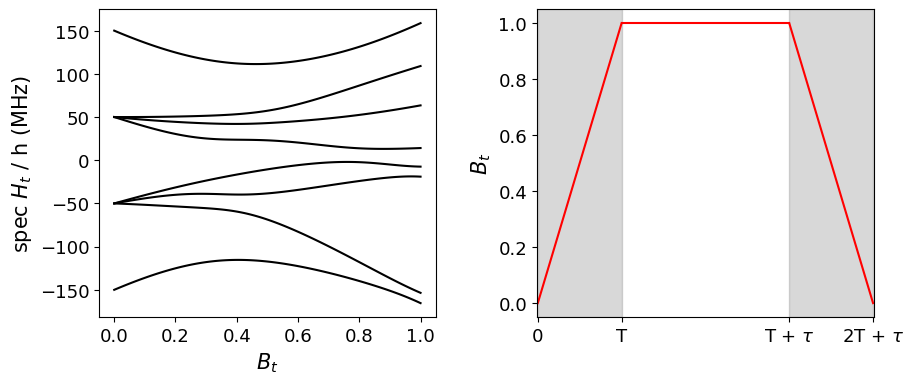

In [ ]:
plt.figure(figsize=(10, 4))
plt.subplots_adjust(wspace=0.3)

plt.subplot(1, 2, 1)
plt.plot(s_axis, spec * 1000 / (2*np.pi), c="black")
plt.xlabel("$B_t$", fontsize=15)
plt.ylabel("spec $H_t$ / h (MHz)", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.subplot(1, 2, 2)
plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), c="red")
plt.plot(np.linspace(1, 3, 100), np.ones(100), c="red")
plt.plot(np.linspace(3, 4, 100), np.linspace(1, 0, 100), c="red")
plt.xlabel("", fontsize=15)
plt.ylabel("$B_t$", fontsize=15)
plt.yticks(fontsize=13)
plt.xticks([0, 1, 3, 4], ["0", f"T", "T + $\\tau$", "2T + $\\tau$"], fontsize=13)
plt.axvspan(0, 1, alpha=0.3, color="gray")
plt.axvspan(3, 4, alpha=0.3, color="gray")
plt.xlim(-0.01, 4.01)

#plt.savefig("spectrum_and_schedule.png", dpi=500, bbox_inches="tight")

## Let's obtain the ramp unitary first

In [7]:
ramp_time = 4.

evals, estates = H2.eigenstates()
B = np.array([0, 1])
A = 1-B
t = [0.0, ramp_time]

Ht = qt.QobjEvo([[H1, A], [H2, B]], tlist=t, order=1)

options={"nsteps": 10000,
        "method": "vern9",
        "atol": 1e-7,
        "rtol": 1e-5,
        "store_states": False,
        "store_final_state": True}

result = qt.sesolve(Ht, initial_state, t, options=options)

unitary_elements = np.zeros(len(evals), dtype=np.complex64)

for m, state in enumerate(estates):
    unitary_elements[m] = state.dag() * result.final_state

target_frequencies = []
for m in range(len(evals)):
    for n in range(m+1, len(evals)):
        target_frequencies.append(np.abs(evals[m]-evals[n]) / (2*np.pi))


# Compute signal

In [8]:
def run_anneal(taus, tau_ramp = 1.0, gamma_dephasing = None, gamma_amplitude_damp = None):

    # run QA ramp
    B = np.array([0, 1])
    A = 1-B
    t = [0, tau_ramp]

    options={"nsteps": 10000,
            "method": "vern9",
            "atol": 1e-7,
            "rtol": 1e-5,
            "store_states": False,
            "store_final_state": True}

    Ht = qt.QobjEvo([[H1, A], [H2, B]], tlist=t, order=1)

    result = qt.sesolve(Ht, initial_state, t, options=options)

    # run waiting time
    """
    options={"nsteps": 100000,
            "method": "vern9",
            "atol": 1e-9,
            "rtol": 1e-7,
            "store_states": True,
            "store_final_state": True}

    Ht = qt.QobjEvo(H2, tlist=t, order=1)
    result = qt.sesolve(H2, result.final_state, taus, options=options)
    phase_evolved_states = result.states
    """

    evals, estates = H2.eigenstates()

    projectors = []
    for state in estates:
        projectors.append(state * state.dag())

    phase_evolved_states = []
    for tau in taus:
        args = (tau * evals) % (2*np.pi)
        unit_evals = np.exp(-1j * args)
        evolved_state = 0
        for unit_eval, proj in zip(unit_evals, projectors):
            evolved_state += unit_eval * proj * result.final_state
        phase_evolved_states.append(evolved_state)

    if gamma_amplitude_damp is not None or gamma_dephasing is not None:
        phase_evolved_states_matrix = []
        for state in phase_evolved_states:
            phase_evolved_states_matrix.append(state * state.dag())

    if gamma_dephasing is not None:
        if type(gamma_dephasing) == float:
            gamma_dephasing = gamma_dephasing * np.zeros(Nq)
        kraus_ops = []
        for n in range(Nq):
            op_list = Nq * [qt.qeye(2)]
            op_list[n] = qt.sigmaz()
            kraus_ops.append(qt.tensor(op_list))

        for m, tau in enumerate(taus):
            state = phase_evolved_states_matrix[m]
            for n in range(Nq):
                p = 0.5 * (1-np.exp(-tau * gamma_dephasing[n]))
                state = (1-p) * state + p * (kraus_ops[n] * state * kraus_ops[n])
            phase_evolved_states_matrix[m] = state
        phase_evolved_states = phase_evolved_states_matrix

    if gamma_amplitude_damp is not None:

        for m, tau in enumerate(taus):
            p = 1-np.exp(-tau * gamma_amplitude_damp)

            kraus_ops_0 = []
            for n in range(Nq):
                op_list = Nq * [qt.qeye(2)]
                op_list[n] = qt.Qobj(np.array([[1., 0.],
                                               [0., np.sqrt(1-p)]]))
                kraus_ops_0.append(qt.tensor(op_list))

            kraus_ops_1 = []
            for n in range(Nq):
                op_list = Nq * [qt.qeye(2)]
                op_list[n] = qt.sigmap() * np.sqrt(p)
                kraus_ops_1.append(qt.tensor(op_list))

            state = phase_evolved_states_matrix[m]
            for n in range(Nq):
                state = kraus_ops_0[n] * state * kraus_ops_0[n].dag() + kraus_ops_1[n] * state * kraus_ops_1[n].dag()

            phase_evolved_states_matrix[m] = state
        phase_evolved_states = phase_evolved_states_matrix

    # run rQA ramp
    B = np.array([1, 0])
    A = 1-B
    t = [0, tau_ramp]

    target_expect = np.zeros(len(taus))
    for m, state in enumerate(phase_evolved_states):
        options={"nsteps": 10000,
            "method": "vern9",
            "atol": 1e-7,
            "rtol": 1e-5,
            "store_states": False,
            "store_final_state": True}

        Ht = qt.QobjEvo([[H1, A], [H2, B]], tlist=t, order=1)
        if gamma_dephasing is not None or gamma_amplitude_damp is not None:
            result = qt.mesolve(Ht, state, t, options=options)
        else:
            result = qt.sesolve(Ht, state, t, options=options)

        target_expect[m] = qt.expect(initial_state_projector, result.final_state)
    
    return target_expect

In [ ]:
taus = np.linspace(1, 16000, 16000, endpoint=False)
T2 = [7500 / 2, 2666, 3000] # energy scale is GHz -> time scale is ns
T1 = 2000
y = run_anneal(taus, tau_ramp=ramp_time, gamma_dephasing=[1/t for t in T2])

In [10]:
print("Decoherence times T2 for each qubit:")
for t in T2:
    print(f"{t/1000} us")

Decoherence times T2 for each qubit:
3.75 us
2.666 us
3.0 us


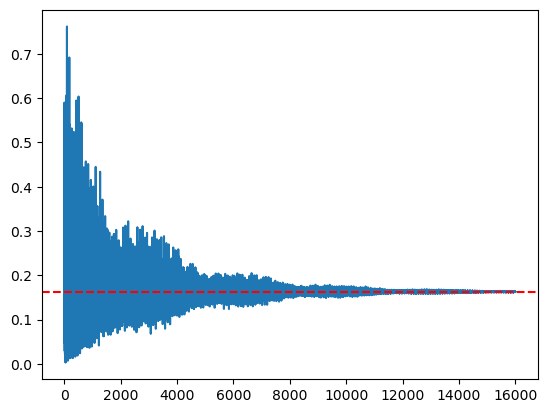

In [11]:
plt.plot(taus, y)
plt.axhline(y.mean(), linestyle="--", c="red")
#plt.xlim(0, 200)

#np.save(f"y_{ramp_time=}.npy", y)

# Reconstruct the signal using Fourier transform

In [12]:
zero_pad_factor = 10000

dt = taus.max() / len(taus)
freqs = np.fft.fftfreq(zero_pad_factor*len(taus), d=dt)
freqs = np.append(freqs[len(freqs) // 2:], freqs[:len(freqs) // 2])

y_ft = fft(y - np.mean(y), n=zero_pad_factor*len(taus))
y_ft = 2*np.append(y_ft[len(freqs) // 2:], y_ft[:len(freqs) // 2]) / len(taus)

In [ ]:
def fit_sinc(x, a, b, c):
    return np.abs(a * np.sinc(b*(x-c)))


def fit_envelope(x, a, b):
    return a / (np.abs(x-b) + 1e-3)


def fit_dirichlet(x, a):
    N = len(x)
    return np.sin((N+0.5)*x) / np.sin(x/2)


def parabolic_log_interp(mag, k):
    # mag is |Y| array, k is peak index (not at edges)
    a = np.log(mag[k-1] + 1e-300)
    b = np.log(mag[k]   + 1e-300)
    c = np.log(mag[k+1] + 1e-300)
    denom = (a - 2*b + c)
    if denom == 0:
        return 0.0
    return 0.5 * (a - c) / denom  # delta in [-0.5, 0.5] typically


def estimate_freqs_from_dft(y, dt, n_tones=6, window="hann", min_bin_gap=3): # ChatGPT suggestion
    y = np.asarray(y)
    M = len(y)
    y0 = y - y.mean()

    if window == "hann":
        w = np.hanning(M)
    elif window == "blackmanharris":
        w = np.blackman(M)  # placeholder; BH is in scipy.signal.windows if you want
    else:
        w = np.ones(M)

    yw = y0 * w
    Y = np.fft.rfft(yw)
    mag = np.abs(Y)
    fs = 1.0 / dt

    # crude peak candidates (exclude DC bin 0)
    candidates = np.argsort(mag)[::-1]

    peaks = []
    for k in candidates:
        if k == 0 or k == len(mag)-1:
            continue
        # local maximum check
        if not (mag[k] >= mag[k-1] and mag[k] >= mag[k+1]):
            continue
        # enforce separation
        if any(abs(k - kp) < min_bin_gap for kp in peaks):
            continue
        peaks.append(k)
        if len(peaks) == n_tones:
            break

    # sub-bin refinement
    freqs = []
    for k in peaks:
        d = parabolic_log_interp(mag, k)
        f = (k + d) * fs / M
        freqs.append(f)

    freqs = np.array(sorted(freqs))
    #omegas = 2*np.pi*freqs
    return freqs


def estimate_cos_parameters(y, x, freqs_estimate): # TODO this is too sensitive to freqency estimation error
    y = y - np.mean(y)
    dx = x[1] - x[0]
    a = np.zeros(len(freqs_estimate))
    b = np.zeros(len(freqs_estimate))
    for m, f in enumerate(freqs_estimate):
        a[m] = 2*np.sum(np.cos(f*x) * y) * dx / (x.max() - x.min())
        b[m] = 2*np.sum(np.sin(f*x) * y) * dx / (x.max() - x.min())

    amplitudes = np.sqrt(a**2 + b**2)
    phases = np.atan2(-b, a)
    return amplitudes, phases


def estimate_cos_parameters_least_squares(y, x, freqs_estimate, adjust_freqs=False):
    y = y - np.mean(y)
    dx = x[1] - x[0]
    T = x.max() - x.min()

    if adjust_freqs:
        def opt_func(params, freqs_estimate):
            As = params[::3]
            Bs = params[1::3]
            frqs_offset = params[2::3]
            y_recon = 0
            for omega, A, B in zip(freqs_estimate + 1e-1*frqs_offset, As, Bs):
                y_recon += A*np.cos(omega*x) + B*np.sin(omega*x)

            return 0.5 * ((y-y_recon)**2).sum() * dx / T

        tol = 1e-12
        print(f"{tol = }")
        x0 = 0.5*np.ones(3*len(freqs_estimate))
        x0[2::3] = 0.
        result = minimize(opt_func, x0, args=(freqs_estimate), tol=tol)
        opt_params = result.x

        As = opt_params[::3]
        Bs = opt_params[1::3]
    else:
        def opt_func(params):
            As = params[::2]
            Bs = params[1::2]
            y_recon = 0
            for omega, A, B in zip(freqs_estimate, As, Bs):
                y_recon += A*np.cos(omega*x) + B*np.sin(omega*x)

            return 0.5 * ((y-y_recon)**2).sum() * dx / T

        tol = 1e-12
        print(f"{tol = }")
        result = minimize(opt_func, 0.5*np.ones(2*len(freqs_estimate)), tol=tol)
        opt_params = result.x

        As = opt_params[::2]
        Bs = opt_params[1::2]

    amplitudes = np.sqrt(As**2 + Bs**2)
    phases = np.atan2(-Bs, As)

    return amplitudes, phases


def estimate_cos_parameters_qr(y, x, omegas): # ChatGPT suggestion!
    """
    Fits y ~ c0 + Σ_k (A_k cos(ω_k x) + B_k sin(ω_k x))
    using a stable linear least-squares solve (QR/SVD under the hood).
    """
    y = y - y.mean()
    y = np.asarray(y)
    x = np.asarray(x)
    omegas = np.asarray(omegas)

    # Build design matrix: [1, cos ω1x, sin ω1x, ..., cos ωNx, sin ωNx]
    cols = [np.ones_like(x)]
    for w in omegas:
        cols.append(np.cos(w * x))
        cols.append(np.sin(w * x))
    X = np.column_stack(cols)

    # Solve min ||X beta - y||_2
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)

    c0 = beta[0]
    As = beta[1::2]
    Bs = beta[2::2]

    amps = np.sqrt(As**2 + Bs**2)
    phases = np.arctan2(-Bs, As)
    return amps, phases


In [14]:
involved_levels = 2**Nq #6
n_tones = int(involved_levels * (involved_levels - 1) // 2)
freqs_estimate = estimate_freqs_from_dft(y, taus[1] - taus[0], n_tones=n_tones)

The reconstruction is not ideal. Maybe we need to use DFT instead of approximate continuous FT, which is sensitive to estimation errors.

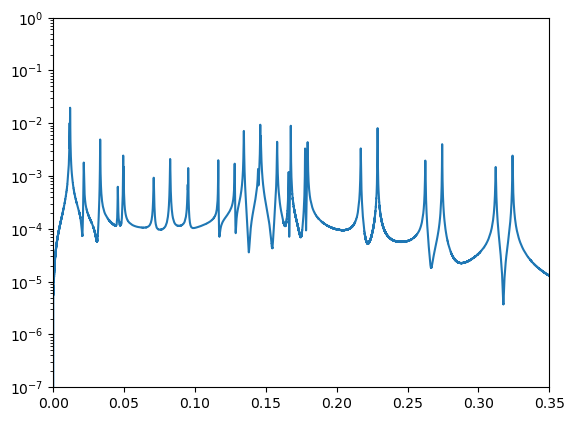

In [15]:
plt.plot(freqs, np.abs(y_ft))

#for omega in freqs_estimate:
#    plt.axvline(omega, color="red", alpha=0.3)

#for omega in target_frequencies:
#    plt.axvline(omega, color="green", linestyle=":")

plt.xlim(0, 0.35)
plt.ylim(1e-7, 1)
plt.yscale("log")

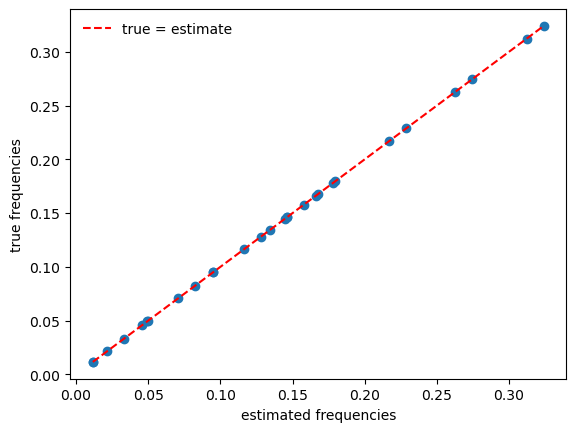

In [16]:
plt.scatter(np.sort(freqs_estimate), np.sort(target_frequencies))
diag = np.linspace(np.min(freqs_estimate), np.max(freqs_estimate), 100)
plt.plot(diag, diag, "--", c="red", label="true = estimate")
plt.xlabel("estimated frequencies")
plt.ylabel("true frequencies")
plt.legend(frameon=False)

# Estimate energies (up to a constant shift and inversion) from frequencies

In [ ]:
def contains(arr, val, slack=1e-5):
    return (np.abs(arr - val) <= slack).any()


def is_sorted(arr):
    return (np.diff(arr) >= 0).all()


def turnpike(stack, distances, energies = [], min_energy=0., max_energy=None, slack=0.01, verbose=False):
    assert (len(energies) > 0 and max_energy is not None) or (len(energies) == 0 and max_energy is None), f"{len(energies)}, {max_energy = }"

    if not is_sorted(stack):
        stack = np.sort(stack)
    if not is_sorted(energies):
        energies = np.sort(energies)

    # break condition for recursion
    if len(stack) == 0:
        return energies

    max_distance = stack[-1]

    if len(energies) == 0:
        new_energies = [0, max_distance]
        new_stack = stack.copy()
        new_stack = new_stack[:-1]
        retval = turnpike(new_stack, distances, energies=new_energies, min_energy=min_energy, max_energy=max_distance, slack=slack)
        # this case has to be successful (except in case of noise)
        return retval    
    else:
        # first branch:
        if verbose:
            print("first branch")
        candidate_energy = max_energy - max_distance
        candidate_distances = np.abs(energies - candidate_energy)
        new_stack = stack.copy()
        if verbose:
            print("pre-remove", new_stack)
            print("energies", energies)
            print("candidate_energy", candidate_energy)
            print("candidate_dist", candidate_distances)

        # check if distances are in stack
        contains_all = True
        for dist in candidate_distances:
            if not contains(new_stack, dist, slack=slack):
                contains_all = False
                break
            else:
                idx = np.argmin(np.abs(dist-new_stack))
                new_stack = np.delete(new_stack, idx)
    
        if contains_all:
            if verbose:
                print("post-remove", new_stack)
            new_energies = np.append(energies, [candidate_energy])
            retval = turnpike(new_stack, distances, energies=new_energies, min_energy=min_energy, max_energy=max_energy, slack=slack)    
        else:
            retval = None

        # if the lower levels return positive result, just pass through:
        if retval is not None:
            return retval

        # second branch:
        if verbose:
            print("second branch")
        candidate_energy = min_energy + max_distance
        candidate_distances = np.abs(energies - candidate_energy)
        new_stack = stack.copy()
        if verbose:
            print("pre-remove", new_stack)
            print("energies", energies)
            print("candidate_energy", candidate_energy)
            print("candidate_dist", candidate_distances)

        # check if distances are in stack
        contains_all = True
        for dist in candidate_distances:
            if not contains(new_stack, dist, slack=slack):
                contains_all = False
                break
            else:
                idx = np.argmin(np.abs(dist-new_stack))
                new_stack = np.delete(new_stack, idx)
    
        if contains_all:
            if verbose:
                print("post-remove", new_stack)
            new_energies = np.append(energies, [candidate_energy])
            retval = turnpike(new_stack, distances, energies=new_energies, min_energy=min_energy, max_energy=max_energy, slack=slack)

        if retval is not None:
            return retval

        # is neither is solvable, raise error
        raise ValueError("Turnpike is not solvable")

In [18]:
nrgs_estimates = turnpike(freqs_estimate, freqs_estimate, slack=0.0001)
print("estimated energies (both solutions): ", nrgs_estimates, np.sort(nrgs_estimates.max() - nrgs_estimates))
print("target energies:", (spec[-1] - spec[-1].min()) / (2*np.pi))

estimated energies (both solutions):  [0.         0.01189095 0.1463913  0.15798245 0.17951228 0.22888098
 0.27443795 0.32410536] [0.         0.04966741 0.09522438 0.14459308 0.16612291 0.17771405
 0.3122144  0.32410536]
target energies: [0.         0.01189112 0.1463917  0.15798351 0.17951234 0.22888109
 0.27443775 0.32410581]


In [ ]:
# pick the right estimate
#nrgs_estimates = np.sort(nrgs_estimates.max() - nrgs_estimates)

(array([-50.,   0.,  50., 100., 150., 200., 250., 300., 350.]),
 [Text(0, -50.0, '−50'),
  Text(0, 0.0, '0'),
  Text(0, 50.0, '50'),
  Text(0, 100.0, '100'),
  Text(0, 150.0, '150'),
  Text(0, 200.0, '200'),
  Text(0, 250.0, '250'),
  Text(0, 300.0, '300'),
  Text(0, 350.0, '350')])

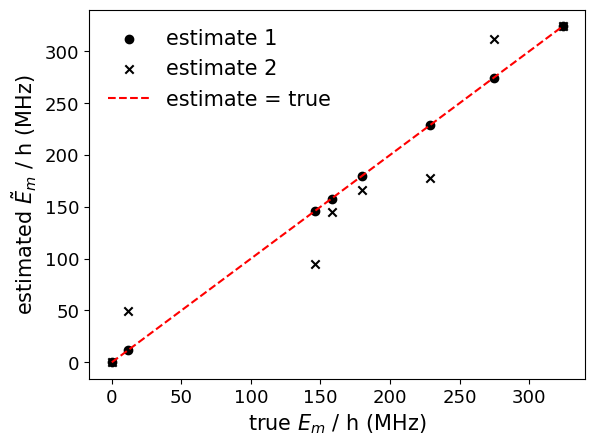

In [20]:
diag = np.linspace(np.min(nrgs_estimates), np.max(nrgs_estimates), 100) * 1000

plt.scatter(np.sort(spec[-1]-spec[-1].min()) * 1000 / (2*np.pi), np.sort(nrgs_estimates) * 1000, c="black", label="estimate 1")
plt.scatter(np.sort(spec[-1]-spec[-1].min()) * 1000 / (2*np.pi), np.sort(nrgs_estimates.max() - nrgs_estimates) * 1000, marker="x", c="black", label="estimate 2")

plt.plot(diag, diag, "--", c="red", label="estimate = true")
plt.ylabel("estimated $\\tilde{E}_m$ / h (MHz)", fontsize=15)
plt.xlabel("true $E_m$ / h (MHz)", fontsize=15)
plt.legend(frameon=False, fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

#plt.savefig("energy_estimates.png", dpi=500, bbox_inches="tight")

# Compute transition amplitudes from estimates energies

In [21]:
A_matrix = np.zeros((len(nrgs_estimates), len(nrgs_estimates)))
phi_matrix = np.zeros((len(nrgs_estimates), len(nrgs_estimates)))

omegas = []
phis = []
for i in range(len(nrgs_estimates)):
    for j in range(i+1, len(nrgs_estimates)):
        e1 = nrgs_estimates[i]
        e2 = nrgs_estimates[j]

        omega = 2*np.pi*np.abs(e2 - e1)
        #amplitude, phase = estimate_cos_parameters(y, taus, [omega])
        amplitude, phase = estimate_cos_parameters_qr(y, taus, [omega])
        A_matrix[i, j] = A_matrix[j, i] = amplitude[0]
        phi_matrix[i, j] = phase[0]
        phi_matrix[j, i] = -phase[0]

        omegas.append(omega)
        phis.append(phase)

In [22]:
unitary_elements_estimate = np.zeros(len(nrgs_estimates))
for i in range(len(unitary_elements_estimate)):
    j = (i+1) % len(unitary_elements_estimate)
    k = (i+2) % len(unitary_elements_estimate)
    unitary_elements_estimate[i] = ( A_matrix[i, j] * A_matrix[i, k] / (2 * A_matrix[j, k]))**(1/4)

unitary_phase_estimate = (phi_matrix[0] / 2)
unitary_phase_estimate += unitary_phase_estimate[0]
unitary_phase_estimate %= np.pi

In [23]:
norm = 0
norm_estimated = 0
mean_error = 0
for elem, elem_estimate, phase_estimate in zip(unitary_elements, unitary_elements_estimate, unitary_phase_estimate):
    print(np.abs(elem), -(np.angle(elem) - np.angle(unitary_elements[0])), elem_estimate, phase_estimate)
    norm += np.abs(elem)**2
    norm_estimated += np.abs(elem_estimate)**2
    mean_error += np.abs(np.abs(elem) - np.abs(elem_estimate)) / len(unitary_elements_estimate)

print(f"{norm = }, {norm_estimated = }, {mean_error = }\n")

0.48669097 -0.0 0.29743937642388985 0.0
0.46840677 -0.020939589 0.24148830703569601 3.0917030088023356
0.41040143 -4.600593 0.3404834637382011 1.548353228786902
0.3285782 -4.586536 0.1359821721038914 1.6928720761098017
0.29836237 -4.385996 0.19084355729365252 1.8746730118598887
0.272536 -3.6469 0.13205537190539945 2.636633279682079
0.22635919 -3.0642438 0.18605343462898452 0.07607130682518741
0.22978161 -2.5218267 0.09798542377720727 0.6188929075245138
norm = np.float32(0.99999994), norm_estimated = np.float64(0.37928383371126395), mean_error = np.float64(0.13734818135130014)



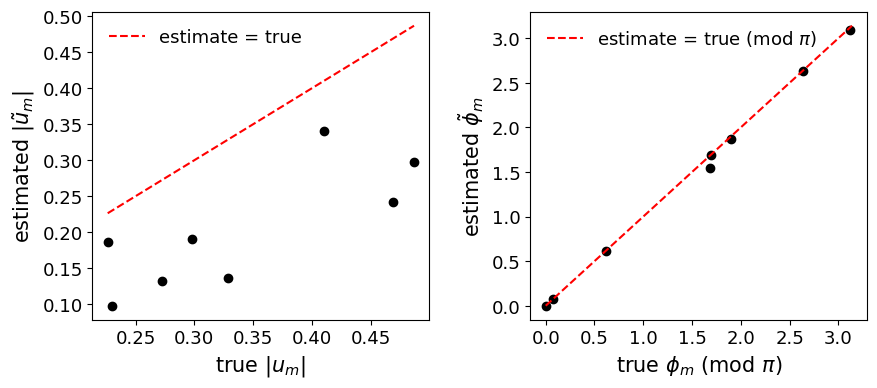

In [24]:
plt.figure(figsize=(10, 4))
plt.subplots_adjust(wspace=.3)
plt.subplot(1, 2, 1)
plt.scatter(np.abs(unitary_elements), np.abs(unitary_elements_estimate), color="black")
diag = np.linspace(np.min(np.abs(unitary_elements)), np.max(np.abs(unitary_elements)), 100)
plt.plot(diag, diag, "--", c="red", label="estimate = true")
plt.ylabel("estimated $|\\tilde{u}_m|$", fontsize=15)
plt.xlabel("true $|u_m|$", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(frameon=False, fontsize=13)

plt.subplot(1, 2, 2)
plt.scatter(-(np.angle(unitary_elements) - np.angle(unitary_elements[0])) % (np.pi), unitary_phase_estimate % (np.pi), color="black")
diag = np.linspace(0., np.pi, 100)
plt.plot(diag, diag, "--", c="red", label=f"estimate = true (mod $\\pi$)")
#plt.plot(diag + np.pi, diag, "--", c="red")
plt.ylabel("estimated $\\tilde{\\phi}_m$", fontsize=15)
plt.xlabel("true $\\phi_m$ (mod $\\pi$)", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(frameon=False, loc="upper left", fontsize=13)

#plt.savefig("amplitudes_result.png", dpi=500, bbox_inches="tight")

# Fit decay parameters

In [25]:
class DecayCurves:
    def __init__(self, freqs, phases):
        self.freqs = freqs
        self.phases = phases

    def __call__(self, t, *params):
        amplitudes = params[::2]
        gammas = params[1::2]

        y = 0
        for A, gam, omega, phi in zip(amplitudes, gammas, self.freqs, self.phases):
            y += A * np.exp(-gam * t) * np.cos(omega * t + phi)
        return y

In [26]:
curve_obj = DecayCurves(omegas, phis)

p0 = 0.05 * np.ones(2*len(freqs_estimate))
p0[1::2] = 5e-4
lb = np.zeros(2*len(freqs_estimate))
ub = 0.1*np.ones(2*len(freqs_estimate))
ub[1::2] = 1e-2
result = curve_fit(curve_obj, taus, y-y.mean(), p0, bounds=(lb, ub), full_output=True, xtol=1e-12)

In [27]:
result[3]

'`ftol` termination condition is satisfied.'

(2000.0, 3000.0)

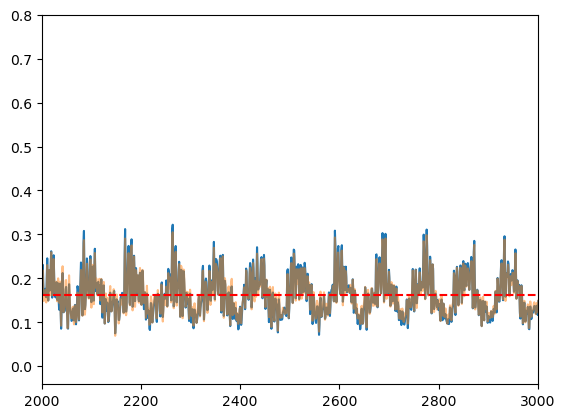

In [28]:
plt.plot(taus, y)
plt.plot(taus, curve_obj(taus, *result[0]) + y.mean(), alpha=0.5)
plt.axhline(y.mean(), linestyle="--", c="red")
plt.xlim(2000, 3000)

# Estimate unitary elements again with fitted amplitudes

In [29]:
A_matrix_noise = np.zeros((len(nrgs_estimates), len(nrgs_estimates)))
phi_matrix_noise = np.zeros((len(nrgs_estimates), len(nrgs_estimates)))

idx_counter = 0
for i in range(len(nrgs_estimates)):
    for j in range(i+1, len(nrgs_estimates)):
        amplitude = result[0][::2][idx_counter]
        phase = result[0][1::2][idx_counter]
        idx_counter += 1

        A_matrix_noise[i, j] = A_matrix_noise[j, i] = amplitude
        phi_matrix_noise[i, j] = phase
        phi_matrix_noise[j, i] = -phase

In [30]:
unitary_elements_estimate_noise = []
for i in range(len(nrgs_estimates)):
    j = (i+1) % len(unitary_elements_estimate)
    k = (i+2) % len(unitary_elements_estimate)

    u = ( A_matrix_noise[i, j] * A_matrix_noise[i, k] / (2 * A_matrix_noise[j, k]))**(1/4)
    unitary_elements_estimate_noise.append(u)

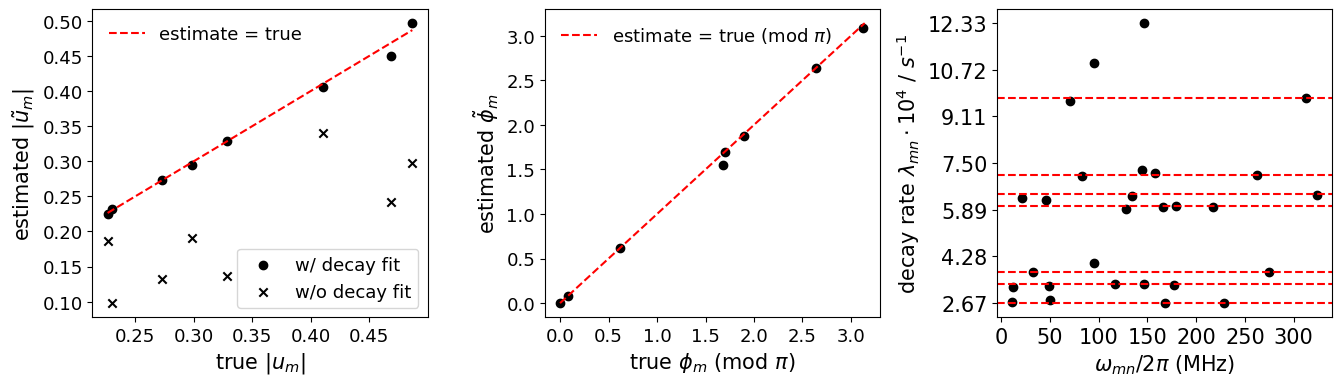

In [ ]:
plt.figure(figsize=(16, 4))
plt.subplots_adjust(wspace=0.35)

plt.subplot(1, 3, 1)
s1 = plt.scatter(np.abs(unitary_elements), unitary_elements_estimate_noise, color="black", label="w/ decay fit")
s2 = plt.scatter(np.abs(unitary_elements), np.abs(unitary_elements_estimate), color="black", marker="x", label="w/o decay fit")
diag = np.linspace(np.min(np.abs(unitary_elements)), np.max(np.abs(unitary_elements)), 100)
d, = plt.plot(diag, diag, "--", c="red", label="estimate = true")
plt.ylabel("estimated $|\\tilde{u}_m|$", fontsize=15)
plt.xlabel("true $|u_m|$", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
l2 = plt.legend([s1, s2], ["w/ decay fit", "w/o decay fit"], frameon=True, fontsize=13, loc="lower right")
plt.legend([d], ["estimate = true"], frameon=False, fontsize=13, loc="upper left")
plt.gca().add_artist(l2)

plt.subplot(1, 3, 2)
plt.scatter(-(np.angle(unitary_elements) - np.angle(unitary_elements[0])) % (np.pi), unitary_phase_estimate % (np.pi), color="black")
diag = np.linspace(0., np.pi, 100)
plt.plot(diag, diag, "--", c="red", label=f"estimate = true (mod $\\pi$)")
#plt.plot(diag + np.pi, diag, "--", c="red")
plt.ylabel("estimated $\\tilde{\\phi}_m$", fontsize=15)
plt.xlabel("true $\\phi_m$ (mod $\\pi$)", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(frameon=False, loc="upper left", fontsize=13)

decay_rates = [1/t for t in T2]

# two-qubit process
for i in range(len(T2)):
    for j in range(i+1, len(T2)):
        decay_rates.append(1/T2[i] + 1/T2[j])

# three-qubit process
for i in range(len(T2)):
    for j in range(i+1, len(T2)):
        for k in range(j+1, len(T2)):
            decay_rates.append(1/T2[i] + 1/T2[j] + 1/T2[k])

decay_rates = np.array(decay_rates)

plt.subplot(1, 3, 3)
plt.plot(np.array(omegas) * 1000 / (2*np.pi), result[0][1::2], "o", color="black")
for rate in decay_rates:
    plt.axhline(rate, color="red", linestyle="--")

plt.xlabel("$\\omega_{mn} / 2 \\pi$ (MHz)", fontsize=15)
plt.ylabel("decay rate $\\lambda_{mn} \\cdot 10^{4}$ / $s^{-1}$", fontsize=15)

plt.xticks(fontsize=15);
plt.yticks(np.linspace(decay_rates.min(), result[0][1::2].max(), len(decay_rates)), [f"{d*10000:.02f}" for d in np.linspace(decay_rates.min(), result[0][1::2].max(), len(decay_rates))], fontsize=15);

#plt.ylim(decay_rates.min()*0.8, decay_rates.max()*1.2)
#plt.savefig("noisy_result.png", dpi=500, bbox_inches="tight")

# Plot spectrum for different ramp times

In [32]:
y1 = np.load("y_ramp_time=4.0.npy")
y2 = np.load("y_ramp_time=12.0.npy")

In [33]:
y_fft_1 = fft(y1 - np.mean(y1), n = zero_pad_factor * len(y1))
y_fft_2 = fft(y2 - np.mean(y2), n = zero_pad_factor * len(y2))

y_fft_1 = 2*np.append(y_fft_1[len(freqs) // 2:], y_fft_1[:len(freqs) // 2]) / len(taus)
y_fft_2 = 2*np.append(y_fft_2[len(freqs) // 2:], y_fft_2[:len(freqs) // 2]) / len(taus)

In [34]:
gap_1 = np.abs(nrgs_estimates[1] - nrgs_estimates[0])
gap_2 = np.abs(nrgs_estimates[-1] - nrgs_estimates[-2])

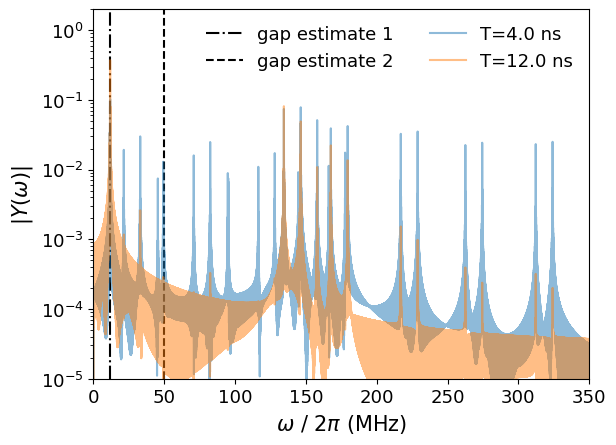

In [35]:
plt.axvline(gap_1 * 1000, linestyle="-.", color="black", label="gap estimate 1")
plt.axvline(gap_2 * 1000, linestyle="--", color="black", label="gap estimate 2")

plt.plot(freqs[::1000] * 1000, np.abs(y_fft_1[::1000]), alpha=0.5, label="T=4.0 ns")
plt.plot(freqs[::1000] * 1000, np.abs(y_fft_2[::1000]), alpha=0.5, label="T=12.0 ns")

plt.yscale("log")
plt.xlim(0, 350)
plt.ylim(1e-5, 2)
plt.xlabel("$\\omega$ / $2 \\pi$ (MHz)", fontsize=15)
plt.ylabel("$|Y(\\omega)|$", fontsize=15)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(frameon=False, fontsize=13, ncols=2)

#plt.savefig("signal_spectrum.png", dpi=500, bbox_inches="tight")

In [ ]:
# def fourier_analysis(pc_list, tw_l, n_peaks=28, prominence_threshold=0.01,
#                      zero_pad_factor=32, window='hann'):
#     """
#     High-resolution spectral analysis returning frequencies, amplitudes, and phases
#     of all detected modes.

#     Techniques used
#     ---------------
#     - DC removal   : subtract mean before windowing to prevent the DC offset
#                      from creating a spurious low-frequency spectral hump.
#     - Hann window  : suppresses spectral leakage from finite observation window.
#     - Zero-padding : interpolates the DFT grid by `zero_pad_factor` for sub-bin
#                      frequency resolution without adding information.
#     - Parabolic interpolation : refines each peak to sub-bin accuracy using the
#                      three-point parabola on log-magnitude.
#     - Phase recovery : reads the complex FFT phase at the detected bin,
#                      corrected for the time-axis offset.

#     Parameters
#     ----------
#     pc_list : array-like
#         Real-valued signal (e.g. ground-state population over time).
#     tw_l : array-like
#         Uniformly spaced time axis.
#     n_peaks : int
#         Maximum number of modes to return.
#     prominence_threshold : float
#         Discard peaks whose amplitude is below this fraction of the largest peak.
#     zero_pad_factor : int
#         Total length of the zero-padded signal = zero_pad_factor * N.
#         Higher values give finer frequency grid (8-16 recommended).
#     window : str
#         Window function passed to ``scipy.signal.get_window``.

#     Returns
#     -------
#     experimental_freqs : np.ndarray   shape (K,)
#         Frequencies [same units as 1/tw_l], sorted by amplitude descending.
#     amplitudes : np.ndarray    shape (K,)
#         Peak amplitudes (corrected for window energy loss).
#     phases : np.ndarray        shape (K,)
#         Phases in radians, referenced to the start of the time axis.
#     """
#     from scipy.signal import find_peaks, get_window

#     y = np.asarray(pc_list, dtype=float)
#     t = np.asarray(tw_l, dtype=float)
#     N = len(y)
#     dt = t[1] - t[0]
#     dc = y.mean()

#     # --- DC removal THEN window ---
#     # Must subtract mean before applying window; otherwise the DC offset
#     # gets multiplied by the window shape and creates a spurious broad peak
#     # near f=0 that can alias into the signal band.
#     win = get_window(window, N)
#     cg = win.sum() / N          # coherent gain for amplitude correction
#     y_win = (y - dc) * win

#     # --- Zero-padded FFT ---
#     N_pad = zero_pad_factor * N
#     spectrum = np.fft.rfft(y_win, n=N_pad)
#     freqs = np.fft.rfftfreq(N_pad, dt)
#     magnitude = np.abs(spectrum)

#     # Skip DC bin (index 0)
#     mag = magnitude[1:]
#     frq = freqs[1:]
#     spc = spectrum[1:]

#     # --- Peak detection ---
#     # min_dist: enforce separation of ~1 original bin in the padded grid
#     min_dist = max(1, zero_pad_factor // 2)
#     # prominence=0.02: low enough to catch weak peaks, high enough to
#     # suppress the sidelobes of the Hann window (which are ~1.5% of peak)
#     peak_locs, _ = find_peaks(mag, distance=min_dist, prominence=0.02 * mag.max())
#     if len(peak_locs) == 0:
#         peak_locs = np.array([np.argmax(mag)])

#     # Filter by amplitude relative to the strongest detected peak
#     threshold = prominence_threshold * mag[peak_locs].max()
#     peak_locs = peak_locs[mag[peak_locs] >= threshold]

#     # Sort by amplitude, keep top n_peaks
#     order = np.argsort(mag[peak_locs])[::-1]
#     peak_locs = peak_locs[order[:n_peaks]]

#     # --- Parabolic interpolation for sub-bin frequency & phase ---
#     freqs_refined = np.empty(len(peak_locs))
#     amplitudes    = np.empty(len(peak_locs))
#     phases        = np.empty(len(peak_locs))

#     log_mag = np.log(mag + 1e-30)

#     for i, k in enumerate(peak_locs):
#         k_l = max(k - 1, 0)
#         k_r = min(k + 1, len(mag) - 1)

#         a_, b_, c_ = log_mag[k_l], log_mag[k], log_mag[k_r]
#         if k_l != k_r:
#             delta = 0.5 * (a_ - c_) / (a_ - 2*b_ + c_ + 1e-30)
#             delta = np.clip(delta, -1.0, 1.0)
#         else:
#             delta = 0.0

#         df = frq[1] - frq[0]
#         freqs_refined[i] = frq[k] + delta * df

#         amp_interp = mag[k] if delta == 0 else (
#             mag[k_l] * (1 - abs(delta)) + mag[min(k_r, len(mag)-1)] * abs(delta))
#         amplitudes[i] = 2.0 * amp_interp / (N * cg)

#         # Phase: angle at nearest bin, corrected for t[0] offset
#         phase_raw = np.angle(spc[k])
#         phases[i] = (phase_raw - 2 * np.pi * freqs_refined[i] * t[0]) % (2 * np.pi)

#     # Re-sort by amplitude
#     order2 = np.argsort(amplitudes)[::-1]
#     freqs_refined = freqs_refined[order2]
#     amplitudes    = amplitudes[order2]
#     phases        = phases[order2]

#     # --- Reconstructed signal for visual validation ---
#     y_rec = np.full(N, dc)
#     for f, a, p in zip(freqs_refined, amplitudes, phases):
#         y_rec += a * np.cos(2 * np.pi * f * t + p)

#     # --- Plots ---
#     x_max = freqs_refined.max() * 1.2
#     colors = plt.cm.tab10.colors

#     fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#     ax = axes[0]
#     ax.plot(t, y, 'b-', lw=1.5, alpha=0.7, label='data')
#     ax.plot(t, y_rec, 'r--', lw=1.5, alpha=0.9, label='reconstruction')
#     ax.set_xlabel('Time')
#     ax.set_ylabel('Signal')
#     ax.set_title('Signal & Reconstruction')
#     ax.legend(fontsize=8)
#     ax.grid(True, alpha=0.3)

#     ax = axes[1]
#     ax.plot(frq, mag, color='#cc4444', lw=1.2)
#     for i, f in enumerate(freqs_refined):
#         ax.axvline(f, color=colors[i % len(colors)], lw=1.0, linestyle='--', alpha=0.8,
#                    label=f'f{i+1}={f:.4f}')
#     ax.set_xlabel('Frequency')
#     ax.set_ylabel('|FFT| (zero-padded, windowed)')
#     ax.set_xlim(0, x_max)
#     ax.set_title('Spectrum (Hann window, zero-padded)')
#     ax.grid(True, alpha=0.3)
#     if len(freqs_refined) <= 10:
#         ax.legend(fontsize=7)

#     ax = axes[2]
#     labels = [f'f{i+1}\n{f:.4f}' for i, f in enumerate(freqs_refined)]
#     ax.bar(labels, amplitudes, color=[colors[i % len(colors)] for i in range(len(amplitudes))])
#     ax.set_xlabel('Mode')
#     ax.set_ylabel('Amplitude')
#     ax.set_title('Mode Amplitudes')
#     ax.grid(True, alpha=0.3, axis='y')
#     plt.setp(ax.get_xticklabels(), fontsize=7)

#     plt.tight_layout()
#     plt.show()

#     rms_data = np.sqrt(np.mean((y - dc)**2))
#     rms_res  = np.sqrt(np.mean((y - y_rec)**2))
#     print(f"Reconstruction residual RMS: {rms_res:.4f}  (signal RMS: {rms_data:.4f}, "
#           f"ratio: {rms_res/rms_data:.3f})")
#     print(f"\n{'#':>3}  {'Frequency':>14}  {'Amplitude':>12}  {'Phase (rad)':>12}  {'Phase (deg)':>12}")
#     print("-" * 60)
#     for i, (f, a, p) in enumerate(zip(freqs_refined, amplitudes, phases)):
#         print(f"{i+1:>3}  {f:>14.6f}  {a:>12.6f}  {p:>12.4f}  {np.degrees(p):>12.4f}")

#     return freqs_refined, amplitudes, phases


# def fit_decay_rates(pc_list, tw_l, freqs_detected, window_width=None, n_windows=50):
#     """
#     For each detected frequency f_mn, fit A_mn(τ) = A_mn_true * exp(-λ_mn * τ)
#     by tracking peak amplitudes across sliding time windows.

#     Parameters
#     ----------
#     freqs_detected : array of frequencies from fourier_analysis()
#     window_width   : width of each time window (defaults to ~1/3 of total time)
#     n_windows      : number of sliding windows

#     Returns
#     -------
#     A_true   : recovered true amplitudes (at τ=0)
#     lambdas  : decay rates λ_mn, one per frequency
#     """
#     from scipy.optimize import curve_fit

#     y = np.asarray(pc_list)
#     t = np.asarray(tw_l)
#     T = t[-1] - t[0]

#     if window_width is None:
#         window_width = T / 3

#     # Slide windows across the time axis
#     centers = np.linspace(t[0] + window_width/2, t[-1] - window_width/2, n_windows)
#     amp_vs_time = np.zeros((len(freqs_detected), n_windows))

#     for j, tc in enumerate(centers):
#         mask = np.abs(t - tc) <= window_width / 2
#         t_win, y_win = t[mask], y[mask]
#         if len(t_win) < 10:
#             continue

#         # FFT on this window
#         dt = t_win[1] - t_win[0]
#         N = len(y_win)
#         win = np.hanning(N)
#         cg = win.sum() / N
#         spectrum = np.fft.rfft((y_win - y_win.mean()) * win)
#         freqs_win = np.fft.rfftfreq(N, dt)

#         # For each detected frequency, find amplitude at nearest bin
#         for i, f in enumerate(freqs_detected):
#             idx = np.argmin(np.abs(freqs_win - f))
#             amp_vs_time[i, j] = 2 * np.abs(spectrum[idx]) / (N * cg)

#     # Fit exponential decay to each frequency's amplitude track
#     A_true = np.zeros(len(freqs_detected))
#     lambdas = np.zeros(len(freqs_detected))

#     for i in range(len(freqs_detected)):
#         amps = amp_vs_time[i]
#         valid = amps > 0
#         if valid.sum() < 3:
#             continue
#         try:
#             popt, _ = curve_fit(
#                 lambda t, A, lam: A * np.exp(-lam * t),
#                 centers[valid], amps[valid],
#                 p0=[amps[valid][0], 1.0],
#                 bounds=([0, 0], [np.inf, np.inf])
#             )
#             A_true[i], lambdas[i] = popt
#         except RuntimeError:
#             A_true[i] = amps[valid][0]  # fallback: use first window

#     return A_true, lambdas, amp_vs_time, centers
